# Documentation 

## Converting from a qiskit circuit to a pyzx diagram and vice versa



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


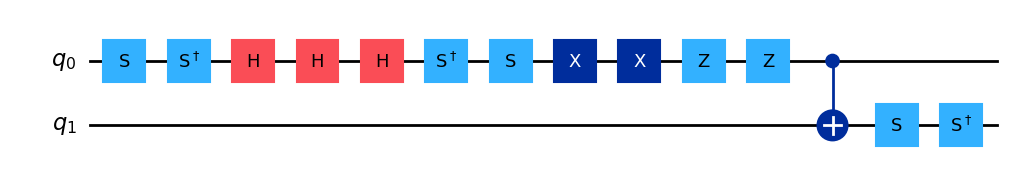

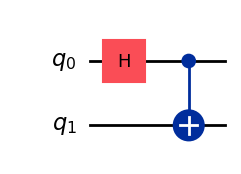

In [9]:
%load_ext autoreload
%autoreload 2
#Get jupyter to display more then one diagrams 
from IPython.display import display
# Make sure you're using the right magic
%matplotlib inline  
# or %matplotlib widget

import pyzx

import qiskit
from qiskit import QuantumCircuit
import pyzx    
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import rewrite
from quantum_optimiser.multimetric import simulated_annealing
   
## Create a very inefficient Quantum Circuit
qc = QuantumCircuit(2)
qc.s(0)
qc.sdg(0)
qc.h(0)
qc.h(0)
qc.h(0)     
qc.sdg(0)
qc.s(0)
qc.x(0)
qc.x(0)     
qc.z(0)
qc.z(0)    

qc.cx(0,1)

qc.s(1)
qc.sdg(1)
qc.draw("mpl")


qc2 = QuantumCircuit(2)
qc2.h(0)
qc2.cx(0,1)
qc2.draw("mpl")


diagram = integration.qiskit_to_pyzx(qc)
#pyzx.draw(diagram)


2
14
0
2
15
0
18


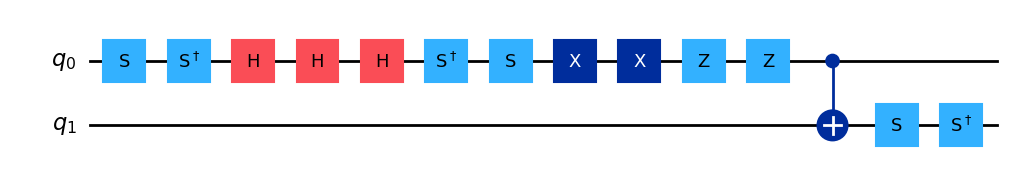

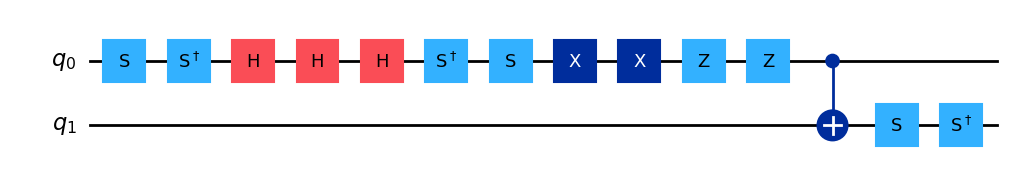

In [10]:
print(metrics.circuit_qubit_count(qc))
print(metrics.circuit_gate_count(qc))
print(metrics.circuit_t_gate_count(qc))


print(metrics.graph_qubit_count(diagram))
print(metrics.graph_gate_count(diagram))
print(metrics.graph_t_gate_count(diagram))
print(metrics.graph_clifford_gate_count(diagram))


integration.pyzx_to_qiskit(diagram)
qc.draw("mpl")


In [11]:
print(loss.naive_loss(qc))
print(loss.informed_loss(qc))

print(loss.naive_loss(qc2))
print(loss.informed_loss(qc2))

6.200000000000001
3.2
1.4
0.8


In [12]:
pyzx.draw(diagram,labels="true")
vertices = (list(diagram.vertices()))
#for i in vertices:
    #print(i)
    #print(rewrite.get_applicable_rules(diagram,i))

new = rewrite.try_fuse(diagram, 6)

print(rewrite.get_applicable_rules(diagram,3))


['color_change', 'fuse_with_2']


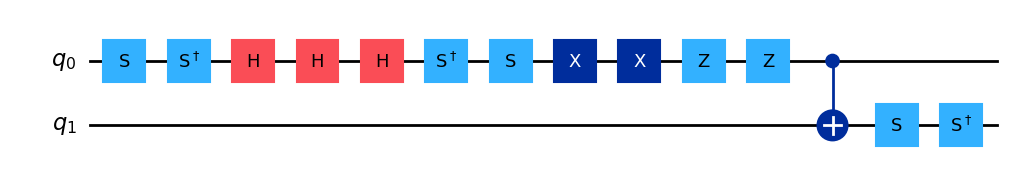

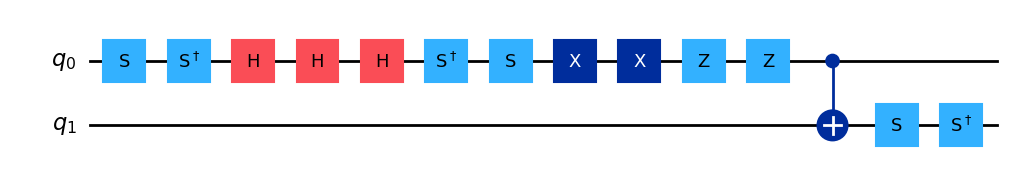

In [13]:
from pyzx import basicrules as br
pyzx.draw(diagram, labels = "true")
pyzx.draw(new,labels="true")
circ = integration.pyzx_to_qiskit(new)
circ.draw("mpl")


True


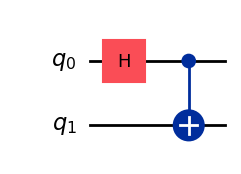

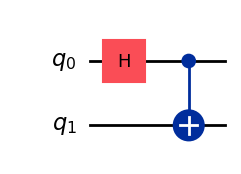

In [14]:
best_diagram, best_cost, history = simulated_annealing.simulated_annealing_zx(
    diagram=diagram,
    cost_function=loss.informed_loss_diagram,
    get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iterations=500
)

pyzx.draw(diagram, labels="true")
pyzx.draw(best_diagram, labels = "true")
print(integration.can_convert_to_circuit(best_diagram))
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

5.98


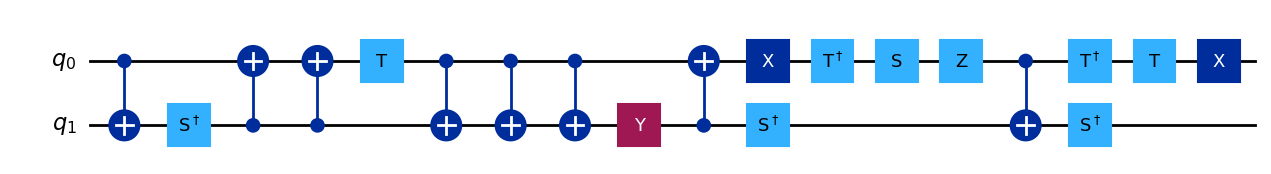

In [47]:
from qiskit.circuit.random import random_clifford_circuit
from qiskit.circuit.random import random_circuit
from qiskit import transpile

from qiskit import QuantumCircuit
import random

def random_clifford_t_circuit_controlled(num_qubits, depth, t_probability=0.2):
    """
    Generate random circuit with controlled T-gate density
    
    Args:
        num_qubits: Number of qubits
        depth: Circuit depth
        t_probability: Probability of T/Tdg gates vs Clifford gates
    """
    circ = QuantumCircuit(num_qubits)
    
    clifford_single = ['h', 'x', 'y', 'z', 's', 'sdg']
    t_gates = ['t', 'tdg']
    
    for _ in range(depth):
        if random.random() < 0.3 and num_qubits > 1:  # Two-qubit gate
            q1, q2 = random.sample(range(num_qubits), 2)
            circ.cx(q1, q2)
        else:  # Single-qubit gate
            qubit = random.randint(0, num_qubits - 1)
            if random.random() < t_probability:
                gate = random.choice(t_gates)
            else:
                gate = random.choice(clifford_single)
            getattr(circ, gate)(qubit)
    
    return circ

# Generate circuit
circ = random_clifford_t_circuit_controlled(2, 20, t_probability=0.25)
circ.draw("mpl")
print(loss.quadratic_loss_circuit(circ))


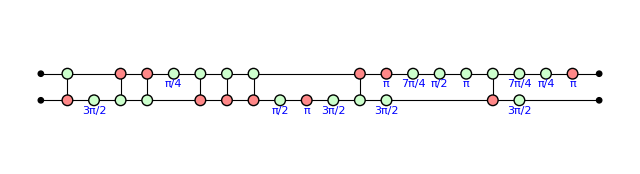

ERROR in cost function (call 1): name 'integration' is not defined
ERROR in cost function (call 2): name 'integration' is not defined
ERROR in cost function (call 3): name 'integration' is not defined
ERROR in cost function (call 4): name 'integration' is not defined
ERROR in cost function (call 5): name 'integration' is not defined
ERROR in cost function (call 6): name 'integration' is not defined
ERROR in cost function (call 7): name 'integration' is not defined
ERROR in cost function (call 8): name 'integration' is not defined
ERROR in cost function (call 9): name 'integration' is not defined
ERROR in cost function (call 10): name 'integration' is not defined
ERROR in cost function (call 11): name 'integration' is not defined
ERROR in cost function (call 12): name 'integration' is not defined
ERROR in cost function (call 13): name 'integration' is not defined
ERROR in cost function (call 14): name 'integration' is not defined
ERROR in cost function (call 15): name 'integration' is n

Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<stri

ERROR in cost function (call 27): name 'integration' is not defined
ERROR in cost function (call 28): name 'integration' is not defined
ERROR in cost function (call 29): name 'integration' is not defined
ERROR in cost function (call 30): name 'integration' is not defined
ERROR in cost function (call 31): name 'integration' is not defined
ERROR in cost function (call 32): name 'integration' is not defined
ERROR in cost function (call 33): name 'integration' is not defined
ERROR in cost function (call 34): name 'integration' is not defined
ERROR in cost function (call 35): name 'integration' is not defined
ERROR in cost function (call 36): name 'integration' is not defined
ERROR in cost function (call 37): name 'integration' is not defined
ERROR in cost function (call 38): name 'integration' is not defined
ERROR in cost function (call 39): name 'integration' is not defined
ERROR in cost function (call 40): name 'integration' is not defined
ERROR in cost function (call 41): name 'integrat

Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<string>", line 11, in wrapper
NameError: name 'integration' is not defined
Traceback (most recent call last):
  File "<stri

In [62]:
new_diagram = integration.qiskit_to_pyzx(circ)
fig =pyzx.draw(new_diagram)
display(fig)
function = loss.cost_function_from_circuit(loss.quadratic_loss_circuit)
best_diagram, best_cost, history = simulated_annealing.simulated_annealing_zx(
    diagram=new_diagram,
    cost_function=function,
    get_neighbor=simulated_annealing.get_neighbor_random_vertex_random_rule,
    initial_temp=100.0,
    cooling_rate=0.95,
    max_iterations=500
)

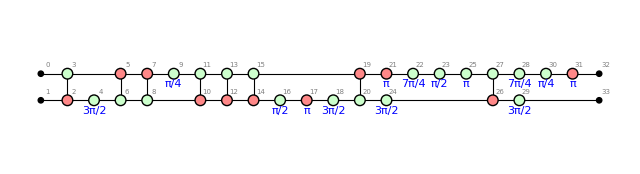

In [54]:
newfig = pyzx.draw(best_diagram, labels = True)
display(newfig)

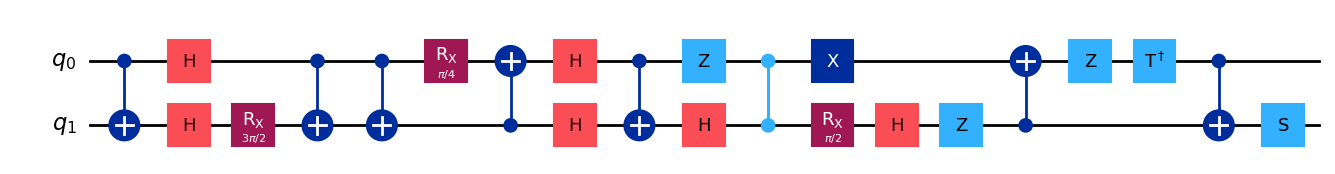

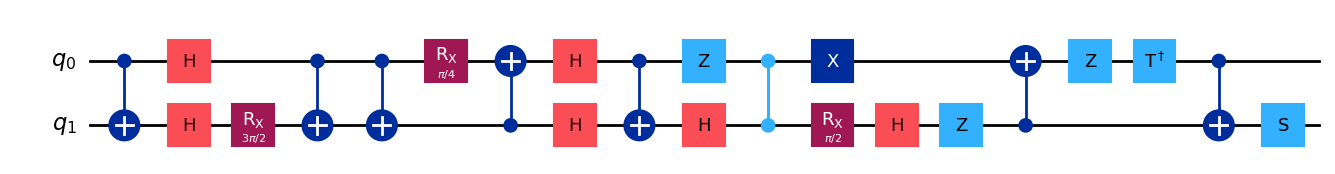

In [50]:
circ2 = integration.pyzx_to_qiskit(best_diagram)
circ2.draw("mpl")

In [51]:
print(loss.quadratic_loss_circuit(circ2))



5.545


=== DIAGNOSTIC INFO ===
PyZX version: 0.9.0
Mode: notebook
Backend: matplotlib
Diagram type: <class 'pyzx.graph.graph_s.GraphS'>
Vertices: 24
Edges: 26
Diagram: Graph(24 vertices, 26 edges)

=== ATTEMPTING TO DRAW ===
Draw returned: Figure(800x200)
Figure type: <class 'matplotlib.figure.Figure'>

=== TRYING TO SAVE TO FILE ===
Saved to diagram_test.png


<Figure size 640x480 with 0 Axes>